In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("cardio_train (1).csv", sep=";")

In [ ]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df.shape

(70000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
df['age_years'] = (df['age'] / 365).astype(int)

In [ ]:
df[['age', 'age_years']].head()

,age,age_years
0,18393,50
1,20228,55
2,18857,51
3,17623,48
4,17474,47


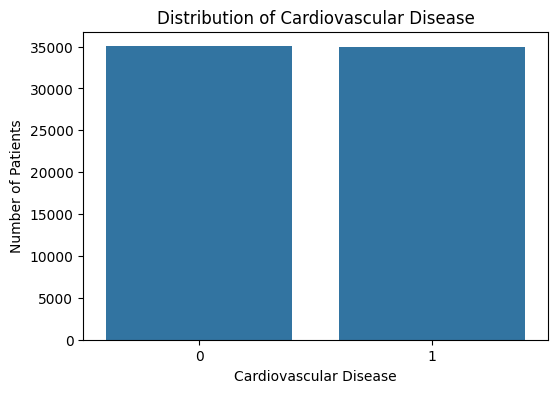

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='cardio', data=df)
plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
df['cardio'].value_counts()

,count
cardio,
0,35021
1,34979


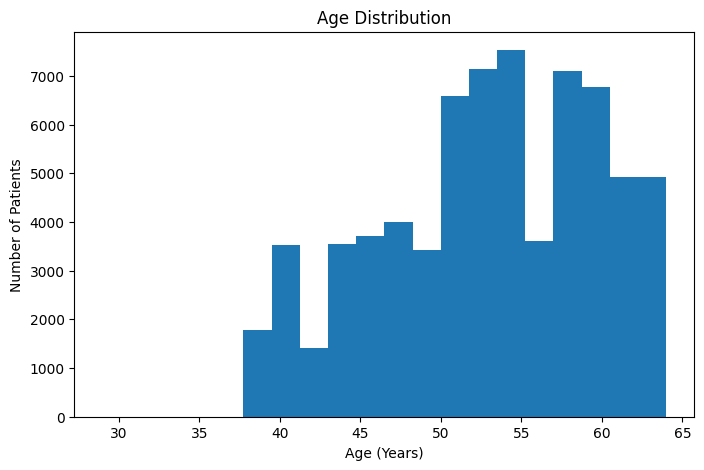

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['age_years'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")
plt.show()

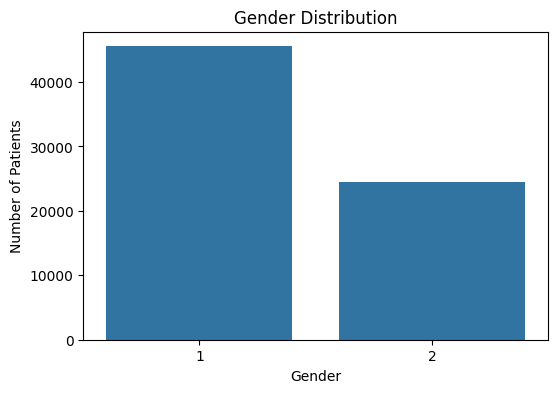

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

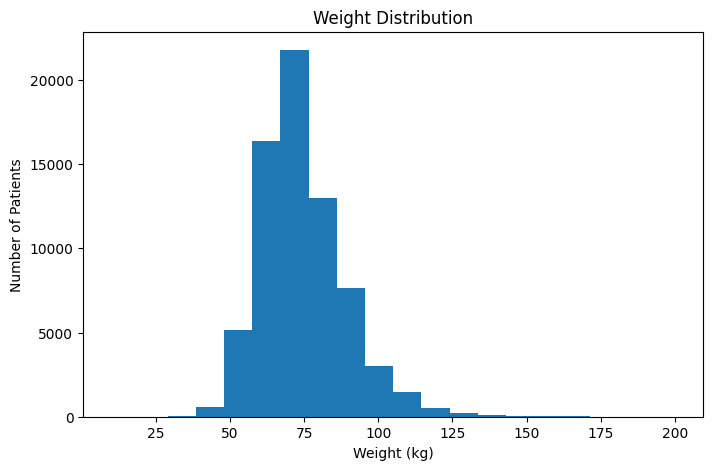

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['weight'], bins=20)
plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Patients")
plt.show()

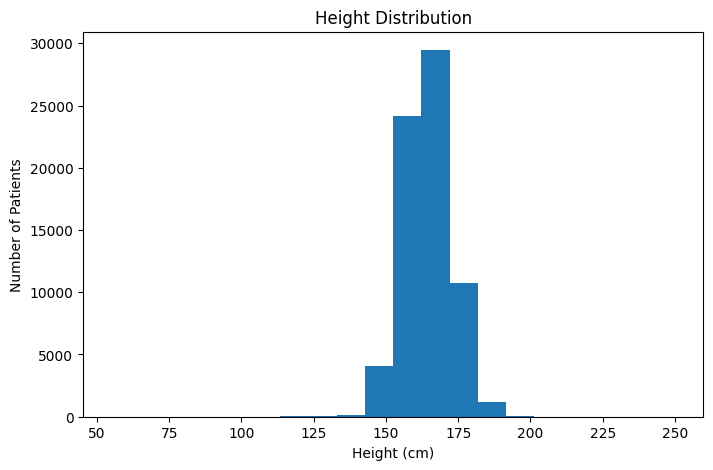

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['height'], bins=20)
plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Number of Patients")
plt.show()

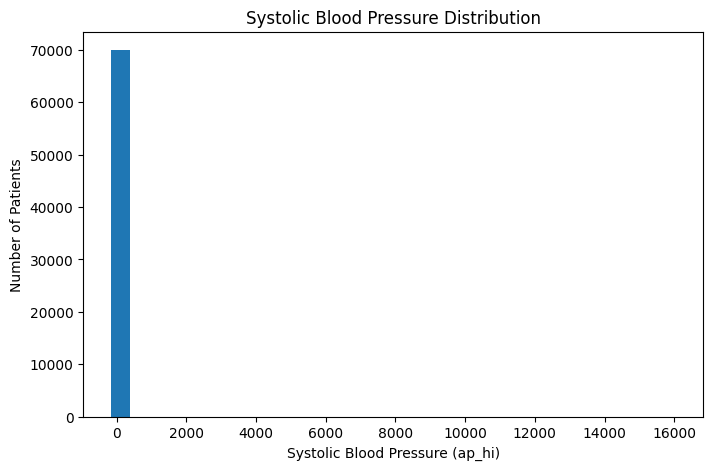

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['ap_hi'], bins=30)
plt.title("Systolic Blood Pressure Distribution")
plt.xlabel("Systolic Blood Pressure (ap_hi)")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
df = df[(df['ap_hi'] > 0) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 0) & (df['ap_lo'] < 200)]

In [ ]:
df.shape

(68985, 14)

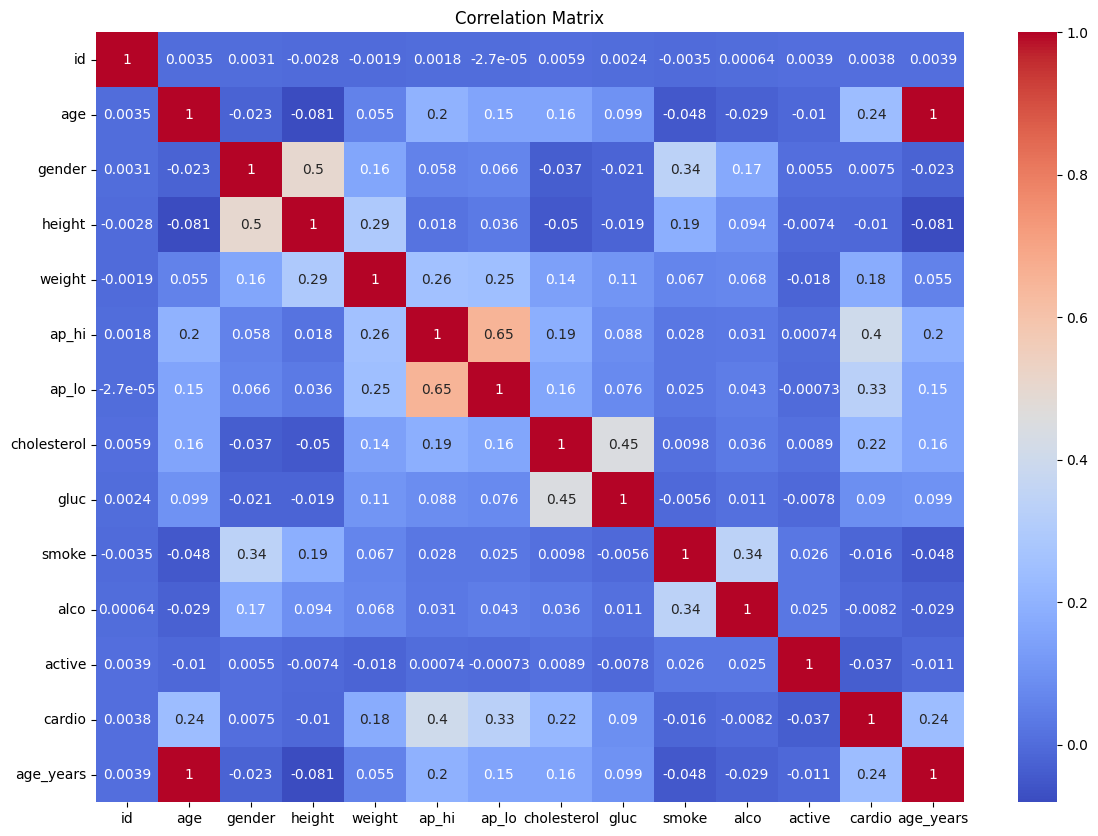

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = df.drop(['cardio'], axis=1)
y = df['cardio']

In [ ]:
X.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,50
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,48
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,47


In [ ]:
y.head()

,cardio
0,0
1,1
2,1
3,1
4,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (55188, 13)
Testing Data: (13797, 13)


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled[:5])

[[-0.02937338  0.13565918 -0.73100197  1.91218455 -0.84457691 -0.3601745
  -0.13633626 -0.53507073 -0.39488644 -0.31173216 -0.23806424  0.49581753
   0.17546963]
 [ 0.48974692  0.354176    1.36798537  1.66752012  0.82679584  1.33523899
   1.90795749  2.420094   -0.39488644 -0.31173216 -0.23806424  0.49581753
   0.32329387]
 [-1.00042514 -1.13814391 -0.73100197 -0.65679197 -1.0534985  -0.3601745
  -1.15848313 -0.53507073 -0.39488644 -0.31173216 -0.23806424  0.49581753
  -1.15494851]
 [ 0.84016784 -0.82516619 -0.73100197 -0.41212754  0.75715531 -0.3601745
  -0.13633626 -0.53507073 -0.39488644 -0.31173216 -0.23806424  0.49581753
  -0.85930003]
 [-0.95380856 -1.94693995 -0.73100197  2.52384562  0.75715531 -0.3601745
  -0.13633626 -0.53507073 -0.39488644 -0.31173216 -0.23806424  0.49581753
  -1.8940697 ]]


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7277669058490976


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.6303544248749728


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7223309415090237


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.6876132492570849


In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC(random_state=42)

svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7350148583025296


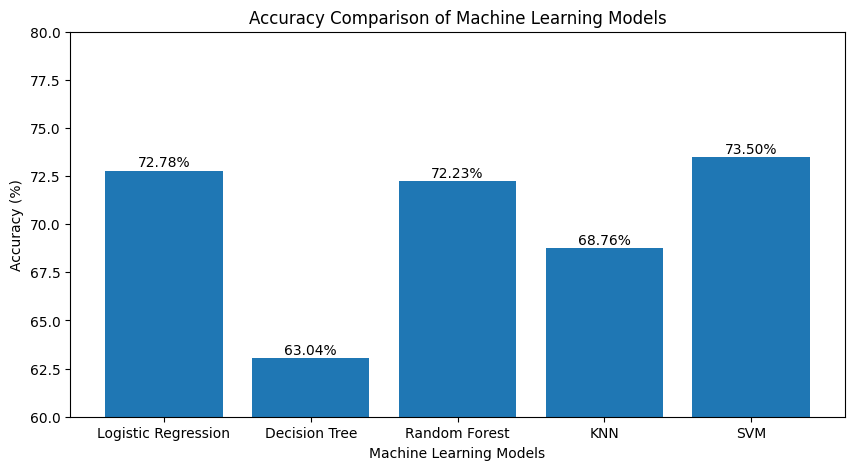

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM']
accuracies = [72.78, 63.04, 72.23, 68.76, 73.50]

plt.figure(figsize=(10,5))
plt.bar(models, accuracies)
plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.ylim(60, 80)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha='center')

plt.show()